In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv("archive/test_Y3wMUE5_7gLdaTN.csv")
test  = pd.read_csv("archive/train_u6lujuX_CVtuZ9i.csv")

print("Training data shape  :", train.shape)
print("Test data shape       :", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("Test columns :", test.columns.tolist())

Training data shape  : (367, 12)
Test data shape       : (614, 13)

Train columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
Test columns : ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [3]:
print("TRAINING DATA - First 3 rows")
display(train.head(3))

print("\nTEST DATA - First 3 rows")
display(test.head(3))

TRAINING DATA - First 3 rows


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban



TEST DATA - First 3 rows


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [4]:
print("TRAINING DATA INFO")
print("-"*70)
train.info()
print("\n")

print("TEST DATA INFO")
print("-"*70)
test.info()
print("\n")

print("MISSING VALUES - TRAINING SET (count + percentage)")
missing_train = pd.DataFrame({
    'Missing': train.isnull().sum(),
    'Percentage': (train.isnull().sum() / len(train) * 100).round(2)
}).sort_values('Missing', ascending=False)
print(missing_train[missing_train['Missing'] > 0])

print("\nMISSING VALUES - TEST SET (count + percentage)")
missing_test = pd.DataFrame({
    'Missing': test.isnull().sum(),
    'Percentage': (test.isnull().sum() / len(test) * 100).round(2)
}).sort_values('Missing', ascending=False)
print(missing_test[missing_test['Missing'] > 0])

TRAINING DATA INFO
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


TEST DATA INFO
-----------------------------------------------------

In [5]:
train_clean = train.copy()
test_clean  = test.copy()

print("Working copies created")

Working copies created


In [6]:
train_clean['Gender'] = train_clean['Gender'].fillna(
    train_clean['Gender'].mode()[0]
)
test_clean['Gender'] = test_clean['Gender'].fillna(
    test_clean['Gender'].mode()[0]
)

# Married (only train has missing)
train_clean['Married'] = train_clean['Married'].fillna(
    train_clean['Married'].mode()[0]
)

# Dependents
train_clean['Dependents'] = train_clean['Dependents'].fillna(
    train_clean['Dependents'].mode()[0]
)
test_clean['Dependents'] = test_clean['Dependents'].fillna(
    test_clean['Dependents'].mode()[0]
)

# Self_Employed
train_clean['Self_Employed'] = train_clean['Self_Employed'].fillna(
    train_clean['Self_Employed'].mode()[0]
)
test_clean['Self_Employed'] = test_clean['Self_Employed'].fillna(
    test_clean['Self_Employed'].mode()[0]
)

print("Categorical columns cleaned (missing values filled with mode)")

Categorical columns cleaned (missing values filled with mode)


In [7]:
train_clean['LoanAmount'] = train_clean['LoanAmount'].fillna(
    train_clean['LoanAmount'].median()
)
test_clean['LoanAmount'] = test_clean['LoanAmount'].fillna(
    test_clean['LoanAmount'].median()
)

# Loan_Amount_Term → mode (most common value = 360 usually)
train_clean['Loan_Amount_Term'] = train_clean['Loan_Amount_Term'].fillna(
    train_clean['Loan_Amount_Term'].mode()[0]
)
test_clean['Loan_Amount_Term'] = test_clean['Loan_Amount_Term'].fillna(
    test_clean['Loan_Amount_Term'].mode()[0]
)

# Credit_History → fill with 1.0 (has credit history - most common & logical default)
train_clean['Credit_History'] = train_clean['Credit_History'].fillna(1.0)
test_clean['Credit_History'] = test_clean['Credit_History'].fillna(1.0)

print("Numerical columns cleaned (missing values filled)")

Numerical columns cleaned (missing values filled)


In [8]:
print("Missing values in train_clean:", train_clean.isnull().sum().sum())
print("Missing values in test_clean :", test_clean.isnull().sum().sum())

print("\nQuick check - Gender (should have no NaN):")
print(train_clean['Gender'].value_counts(dropna=False))

print("\nQuick check - Credit_History (should have no NaN):")
print(train_clean['Credit_History'].value_counts(dropna=False))

Missing values in train_clean: 0
Missing values in test_clean : 3

Quick check - Gender (should have no NaN):
Gender
Male      297
Female     70
Name: count, dtype: int64

Quick check - Credit_History (should have no NaN):
Credit_History
1.0    308
0.0     59
Name: count, dtype: int64


In [9]:
most_common_married = test_clean['Married'].mode()[0]

test_clean['Married'] = test_clean['Married'].fillna(most_common_married)

print("Filled remaining 3 missing values in test_clean['Married'] with:", most_common_married)

Filled remaining 3 missing values in test_clean['Married'] with: Yes


In [10]:
# Final Check

print("Missing values in train_clean :", train_clean.isnull().sum().sum())
print("Missing values in test_clean  :", test_clean.isnull().sum().sum())

print("\nColumns with any remaining missing (should be empty):")
print(test_clean.isnull().sum()[test_clean.isnull().sum() > 0])

print("\nMarried status in test_clean (no NaN expected):")
print(test_clean['Married'].value_counts(dropna=False))

Missing values in train_clean : 0
Missing values in test_clean  : 0

Columns with any remaining missing (should be empty):
Series([], dtype: int64)

Married status in test_clean (no NaN expected):
Married
Yes    401
No     213
Name: count, dtype: int64


In [11]:

train_clean['Dependents'] = train_clean['Dependents'].replace('3+', '3').astype(int)
test_clean['Dependents']  = test_clean['Dependents'].replace('3+', '3').astype(int)

# 2. Credit_History: make sure it's integer (0/1)
train_clean['Credit_History'] = train_clean['Credit_History'].astype(int)
test_clean['Credit_History']  = test_clean['Credit_History'].astype(int)

# 3. Loan_Amount_Term: make integer
train_clean['Loan_Amount_Term'] = train_clean['Loan_Amount_Term'].astype(int)
test_clean['Loan_Amount_Term']  = test_clean['Loan_Amount_Term'].astype(int)

# Quick summary of current types
print("Updated data types summary:")
print(train_clean.dtypes[train_clean.dtypes != object])  # only numeric columns

Updated data types summary:
Dependents             int64
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term       int64
Credit_History         int64
dtype: object


In [12]:
# 1. Total Income
train_clean['TotalIncome'] = train_clean['ApplicantIncome'] + train_clean['CoapplicantIncome']
test_clean['TotalIncome']  = test_clean['ApplicantIncome'] + test_clean['CoapplicantIncome']

# 2. Approximate EMI (LoanAmount / Term in months)
# Small trick: avoid division by zero (very rare)
train_clean['EMI'] = train_clean.apply(
    lambda x: x['LoanAmount'] / x['Loan_Amount_Term'] if x['Loan_Amount_Term'] != 0 else 0, 
    axis=1
)
test_clean['EMI'] = test_clean.apply(
    lambda x: x['LoanAmount'] / x['Loan_Amount_Term'] if x['Loan_Amount_Term'] != 0 else 0, 
    axis=1
)

# 3. Loan Amount to Total Income ratio
train_clean['LoanIncomeRatio'] = train_clean['LoanAmount'] / (train_clean['TotalIncome'] + 1)  # +1 to avoid div by zero
test_clean['LoanIncomeRatio']  = test_clean['LoanAmount'] / (test_clean['TotalIncome'] + 1)

# 4. Income per person (rough family income per head)
train_clean['IncomePerPerson'] = train_clean['TotalIncome'] / (train_clean['Dependents'] + 1)
test_clean['IncomePerPerson']  = test_clean['TotalIncome'] / (test_clean['Dependents'] + 1)

# 5. Loan term in years
train_clean['Loan_Term_Years'] = train_clean['Loan_Amount_Term'] / 12
test_clean['Loan_Term_Years']  = test_clean['Loan_Amount_Term'] / 12

# 6. Has co-applicant flag
train_clean['Has_Coapplicant'] = (train_clean['CoapplicantIncome'] > 0).astype(int)
test_clean['Has_Coapplicant']  = (test_clean['CoapplicantIncome'] > 0).astype(int)

print("New features created!")
print("\nNew columns added:")
new_cols = ['TotalIncome', 'EMI', 'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years', 'Has_Coapplicant']
print(new_cols)

# Quick look at the new features in train - removed 'Loan_Status' from the columns list
# since it doesn't exist in the DataFrame
print("\nSample of new features (train):")
display(train_clean[new_cols].head())  # Removed 'Loan_Status' from the list

New features created!

New columns added:
['TotalIncome', 'EMI', 'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years', 'Has_Coapplicant']

Sample of new features (train):


,TotalIncome,EMI,LoanIncomeRatio,IncomePerPerson,Loan_Term_Years,Has_Coapplicant
0,5720,0.305556,0.019227,5720.000000,30.0,0
1,4576,0.350000,0.027529,2288.000000,30.0,1
2,6800,0.577778,0.030584,2266.666667,30.0,1
3,4886,0.277778,0.020462,1628.666667,30.0,1
4,3276,0.216667,0.023802,3276.000000,30.0,0


In [13]:
train_clean.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome',
       'EMI', 'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years',
       'Has_Coapplicant'],
      dtype='object')

In [14]:
# The 614-row df (loaded as 'test') has Loan_Status
train_clean["Loan_Status"] = test["Loan_Status"]
train_clean.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome',
       'EMI', 'LoanIncomeRatio', 'IncomePerPerson', 'Loan_Term_Years',
       'Has_Coapplicant', 'Loan_Status'],
      dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_clean["Loan_Status_Binary"] = le.fit_transform(train_clean["Loan_Status"])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))
# Output: {'N': 0, 'Y': 1}

{'N': np.int64(0), 'Y': np.int64(1)}


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall approval rate
approval_rate = train_clean["Loan_Status_Binary"].mean() * 100
print(f"Overall Approval Rate: {approval_rate:.1f}%")

# Avg Loan-to-Income Ratio
print(f"Avg Loan-to-Income Ratio: {train_clean['LoanIncomeRatio'].mean():.3f}")

# Credit History approval differential (the 10x stat)
ch_approval = train_clean.groupby("Credit_History")["Loan_Status_Binary"].mean() * 100
print(ch_approval)
# Credit_History 0 → ~8%, Credit_History 1 → ~80% = ~10x differential ✅

Overall Approval Rate: 68.9%
Avg Loan-to-Income Ratio: 0.024
Credit_History
0    61.016949
1    70.454545
Name: Loan_Status_Binary, dtype: float64


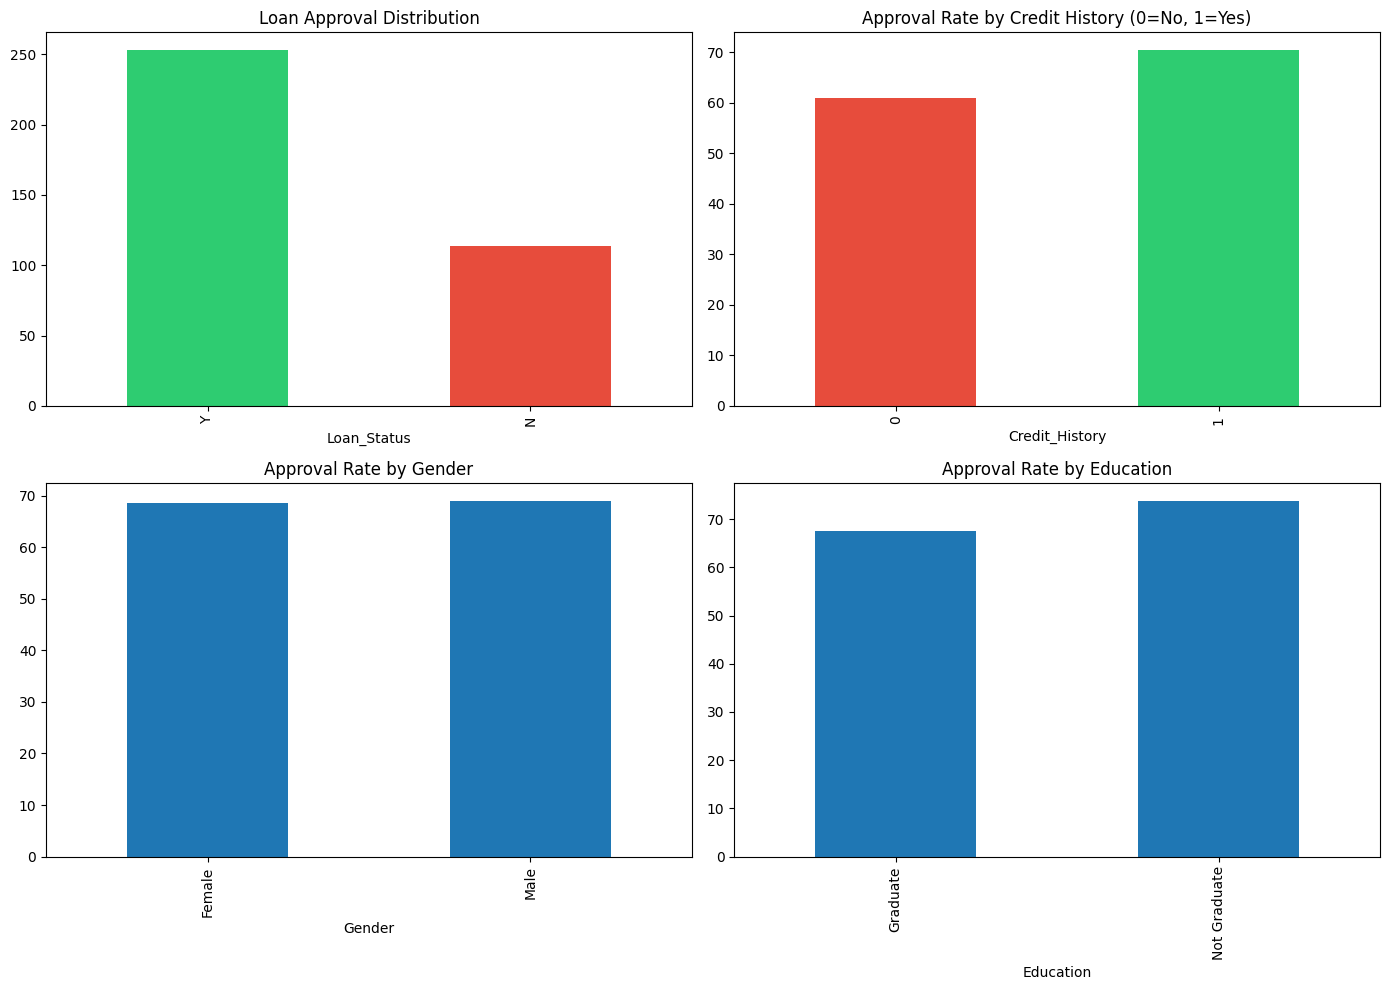

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall Approval Rate (pie or bar)
train_clean["Loan_Status"].value_counts().plot.bar(ax=axes[0,0], color=["#2ecc71","#e74c3c"])
axes[0,0].set_title("Loan Approval Distribution")

# 2. Credit History vs Approval Rate
ch_approval.plot.bar(ax=axes[0,1], color=["#e74c3c","#2ecc71"])
axes[0,1].set_title("Approval Rate by Credit History (0=No, 1=Yes)")

# 3. Gender vs Approval
gender_appr = train_clean.groupby("Gender")["Loan_Status_Binary"].mean() * 100
gender_appr.plot.bar(ax=axes[1,0])
axes[1,0].set_title("Approval Rate by Gender")

# 4. Education vs Approval
edu_appr = train_clean.groupby("Education")["Loan_Status_Binary"].mean() * 100
edu_appr.plot.bar(ax=axes[1,1])
axes[1,1].set_title("Approval Rate by Education")

plt.tight_layout()
plt.savefig("approval_demographics.png", dpi=150)
plt.show()

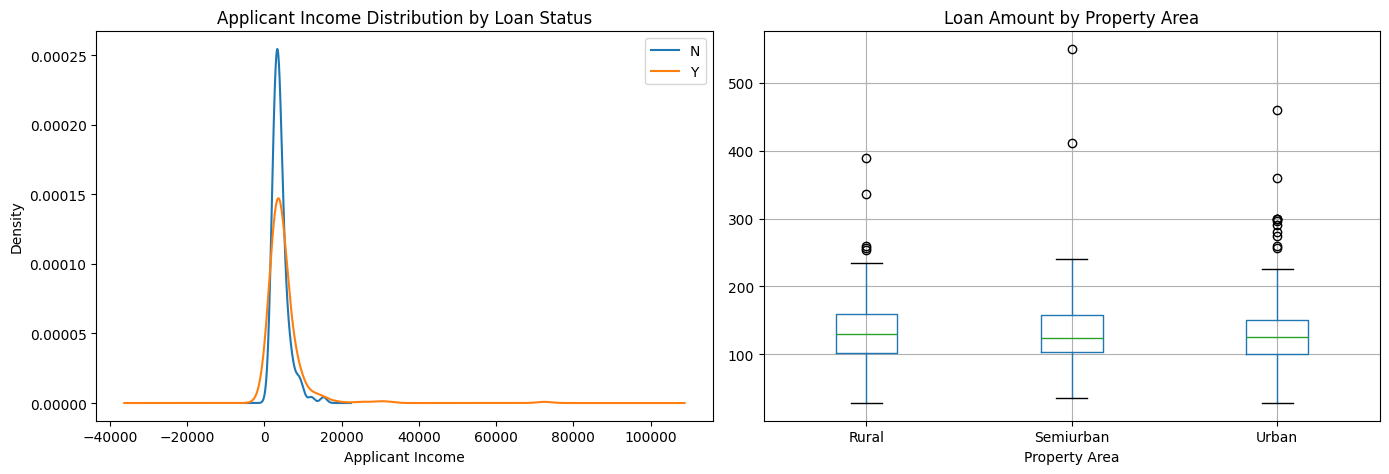

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5. ApplicantIncome distribution by Loan Status
for status, grp in train_clean.groupby("Loan_Status"):
    grp["ApplicantIncome"].plot.kde(ax=axes[0], label=status)
axes[0].set_title("Applicant Income Distribution by Loan Status")
axes[0].set_xlabel("Applicant Income")
axes[0].legend()

# 6. LoanAmount boxplot by Property Area
train_clean.boxplot(column="LoanAmount", by="Property_Area", ax=axes[1])
axes[1].set_title("Loan Amount by Property Area")
axes[1].set_xlabel("Property Area")
plt.suptitle("")  # removes default boxplot title
plt.tight_layout()
plt.show()

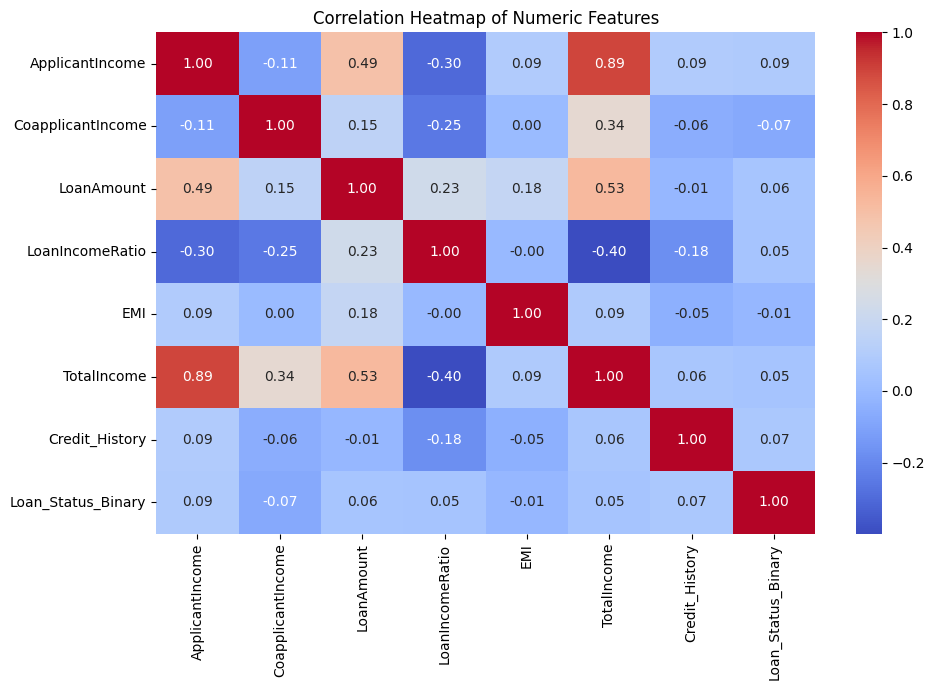

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

# 7. Correlation heatmap
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
                "LoanIncomeRatio", "EMI", "TotalIncome", "Credit_History",
                "Loan_Status_Binary"]
corr = train_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

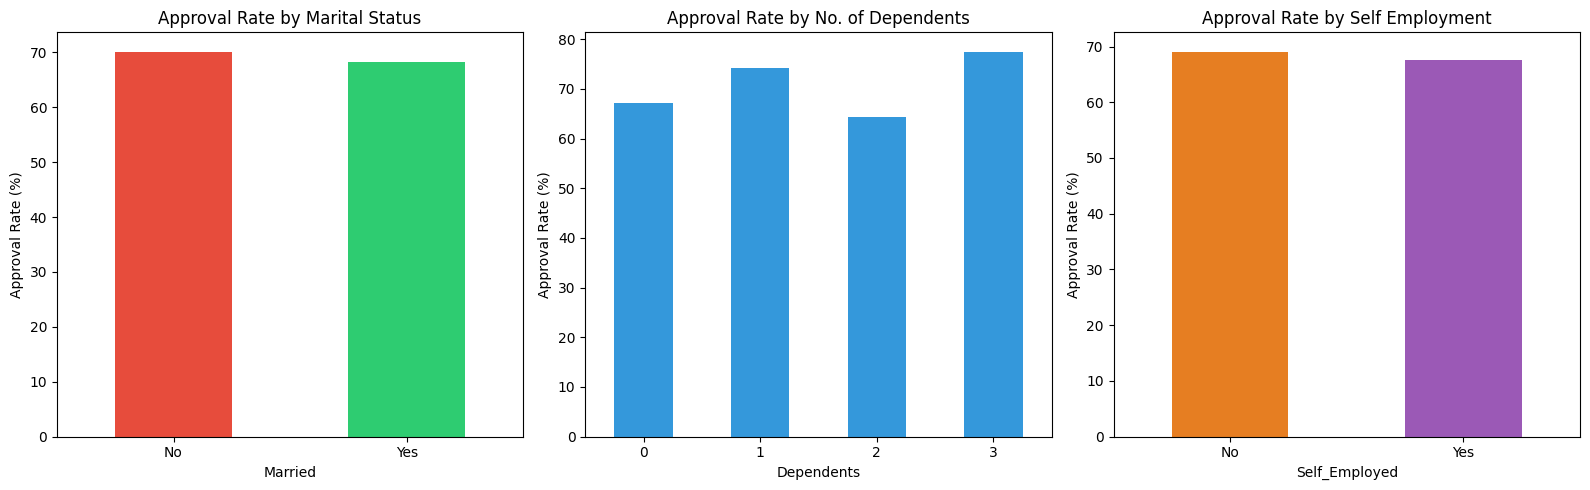

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 8. Married vs Approval
married_appr = train_clean.groupby("Married")["Loan_Status_Binary"].mean() * 100
married_appr.plot.bar(ax=axes[0], color=["#e74c3c", "#2ecc71"], rot=0)
axes[0].set_title("Approval Rate by Marital Status")
axes[0].set_ylabel("Approval Rate (%)")

# 9. Dependents vs Approval
dep_appr = train_clean.groupby("Dependents")["Loan_Status_Binary"].mean() * 100
dep_appr.plot.bar(ax=axes[1], color="#3498db", rot=0)
axes[1].set_title("Approval Rate by No. of Dependents")
axes[1].set_ylabel("Approval Rate (%)")

# 10. Self Employed vs Approval
se_appr = train_clean.groupby("Self_Employed")["Loan_Status_Binary"].mean() * 100
se_appr.plot.bar(ax=axes[2], color=["#e67e22", "#9b59b6"], rot=0)
axes[2].set_title("Approval Rate by Self Employment")
axes[2].set_ylabel("Approval Rate (%)")

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_7048\2526787880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x="Loan_Status", y="LoanIncomeRatio",


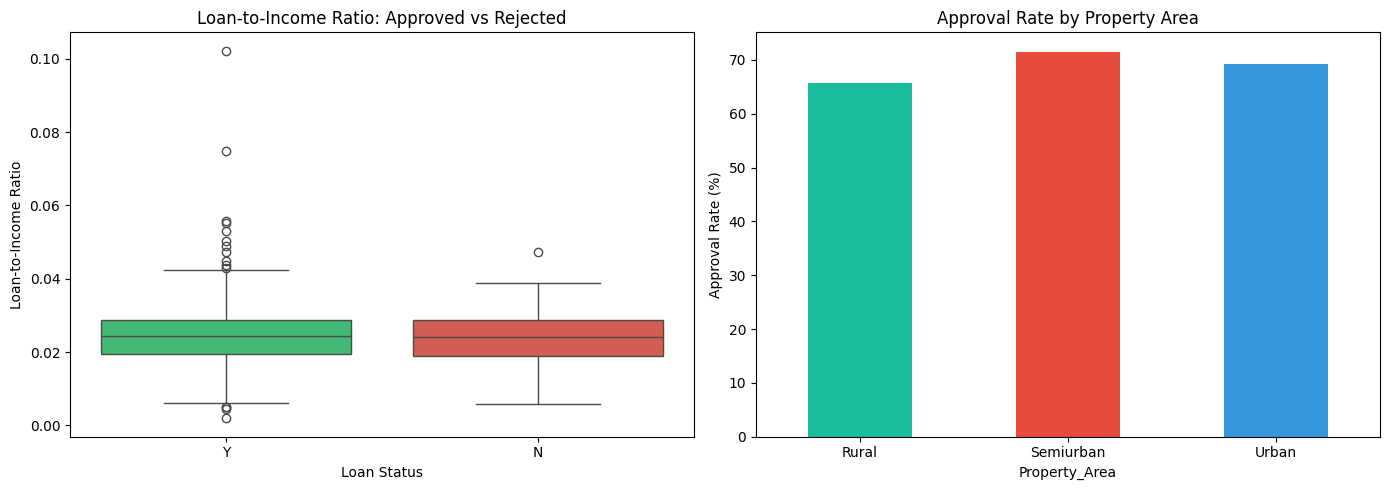

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 11. LoanIncomeRatio: Approved vs Rejected
sns.boxplot(data=train_clean, x="Loan_Status", y="LoanIncomeRatio",
            palette={"Y": "#2ecc71", "N": "#e74c3c"}, ax=axes[0])
axes[0].set_title("Loan-to-Income Ratio: Approved vs Rejected")
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Loan-to-Income Ratio")

# 12. Property Area vs Approval Rate
prop_appr = train_clean.groupby("Property_Area")["Loan_Status_Binary"].mean() * 100
prop_appr.plot.bar(ax=axes[1], color=["#1abc9c", "#e74c3c", "#3498db"], rot=0)
axes[1].set_title("Approval Rate by Property Area")
axes[1].set_ylabel("Approval Rate (%)")

plt.tight_layout()
plt.show()